In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import torch

In [2]:
# load the full dataset

df = pd.read_parquet('../sorted_data.parquet')

In [3]:
df["occ"] = df.groupby(["user_id", "track_id"]).cumcount()

In [4]:
nth_df = df[df["occ"] == 49]

In [5]:
first_df = df[df["occ"] == 0]

In [6]:
result = nth_df.merge(
    first_df,
    on=["user_id", "track_id"],
    suffixes=("_nth", "_first")
)


In [7]:
result

,user_id,track_id,ts_nth,occ_nth,ts_first,occ_first
0,26,123,1656991051,49,1654063157,0
1,26,1778,1658532922,49,1654063157,0
2,26,2548,1659029655,49,1654126622,0
3,26,1462,1660936255,49,1654203346,0
4,26,2426,1661762981,49,1654063157,0
...,...,...,...,...,...,...
7516,13201,614,1661303640,49,1658348758,0
7517,13201,800,1661309008,49,1658348343,0
7518,13201,464,1661316316,49,1656040091,0
7519,13201,890,1661321440,49,1658526354,0


In [8]:
def get_norm(weights, user, item):
    user_emb = weights['model_state_dict']['embedding_user.weight'].cpu().numpy()[user]
    item_emb = weights['model_state_dict']['embedding_item.weight'].cpu().numpy()[item]
    norm = max(np.linalg.norm(user_emb - item_emb), 0)
    return norm

def get_interest(weights, user, item, norm):   
    alpha = weights['model_state_dict']['alpha'].cpu().numpy()
    beta = weights['model_state_dict']['beta'].cpu().numpy()
    gamma = weights['model_state_dict']['gamma'].cpu().numpy()
    u_bias = weights['model_state_dict']['user_bias.weight'].cpu().numpy()[user]
    i_bias = weights['model_state_dict']['item_bias.weight'].cpu().numpy()[item]
    
    interest = alpha * norm + beta * norm**2 + gamma# + u_bias + i_bias

    return interest

In [9]:
from sklearn.decomposition import PCA

In [11]:
models = ['original', 'extended']
# just first split is good enough

for m in models:
    weights = torch.load(f'../checkpoints/{m}/split_0/checkpoint_best.pt')
    W = weights['model_state_dict']['embedding_item.weight'].detach().cpu().float().numpy()

    pca = PCA(n_components=2)
    W_2d = pca.fit_transform(W)

    
    
    result[f'{m}_norm_first'] = result.apply(lambda x: float(get_norm(weights, int(x['user_id']), int(x['track_id']))), axis=1)
    result[f'{m}_interest_first'] = result.apply(lambda x: get_interest(weights, int(x['user_id']), int(x['track_id']), x[f'{m}_norm_first']), axis=1)
    result[f'{m}_emb_dim1'] = result.apply(lambda x: float(W_2d[int(x['track_id'])][0]), axis=1)
    result[f'{m}_emb_dim2'] = result.apply(lambda x: float(W_2d[int(x['track_id'])][1]), axis=1)


In [12]:
result

,user_id,track_id,ts_nth,occ_nth,ts_first,occ_first,original_norm_first,original_interest_first,original_emb_dim1,original_emb_dim2,extended_norm_first,extended_interest_first,extended_emb_dim1,extended_emb_dim2
0,26,123,1656991051,49,1654063157,0,8.682245,20.791579,4.102709,-0.338211,13.107400,-20.760992,0.273745,-2.224050
1,26,1778,1658532922,49,1654063157,0,9.343121,22.825294,-1.223208,-0.681878,12.252256,-19.524775,1.686536,2.909924
2,26,2548,1659029655,49,1654126622,0,9.151823,22.262956,-1.622320,-0.472056,13.632423,-21.514161,1.736018,3.927212
3,26,1462,1660936255,49,1654203346,0,9.621901,23.606365,1.587534,-1.284382,12.498317,-19.881690,1.820323,2.080458
4,26,2426,1661762981,49,1654063157,0,9.053795,21.966475,0.063263,-0.876510,13.478080,-21.293208,2.026106,1.930623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7516,13201,614,1661303640,49,1658348758,0,9.555494,23.424447,2.490433,-1.473778,10.546562,-17.023906,1.530500,-1.833902
7517,13201,800,1661309008,49,1658348343,0,9.308327,22.724611,0.312367,-2.209686,10.004169,-16.218864,3.365564,-1.871806
7518,13201,464,1661316316,49,1656040091,0,9.515488,23.313602,0.962837,-2.948035,9.522795,-15.500432,5.142496,-2.201032
7519,13201,890,1661321440,49,1658526354,0,8.832761,21.277289,-0.366491,-1.704584,9.311689,-15.184192,3.728531,-2.186111


original
extended


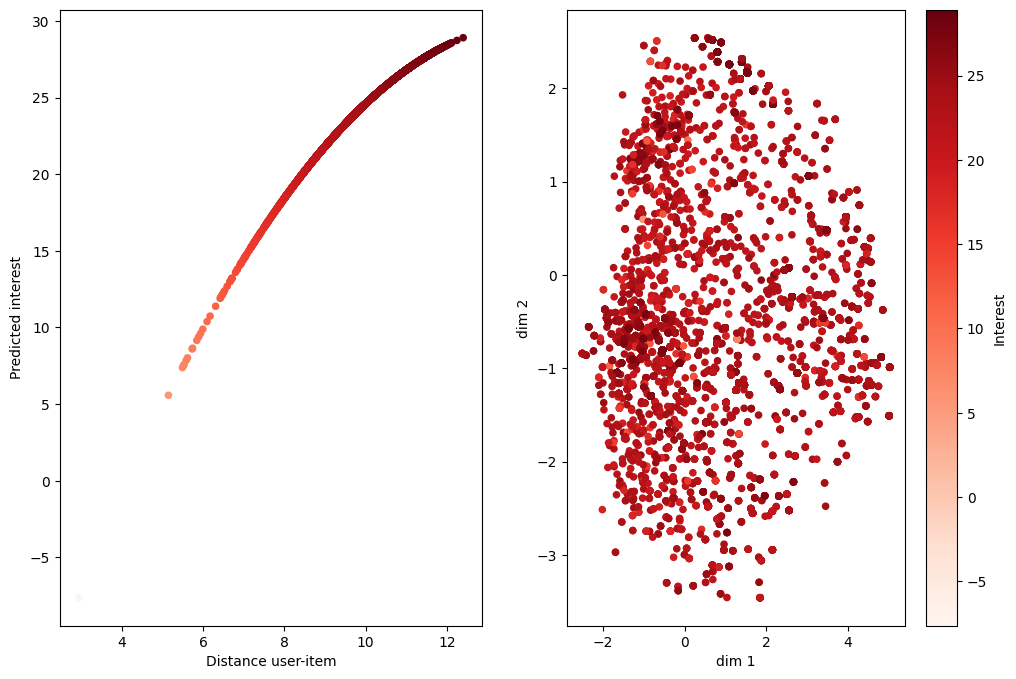

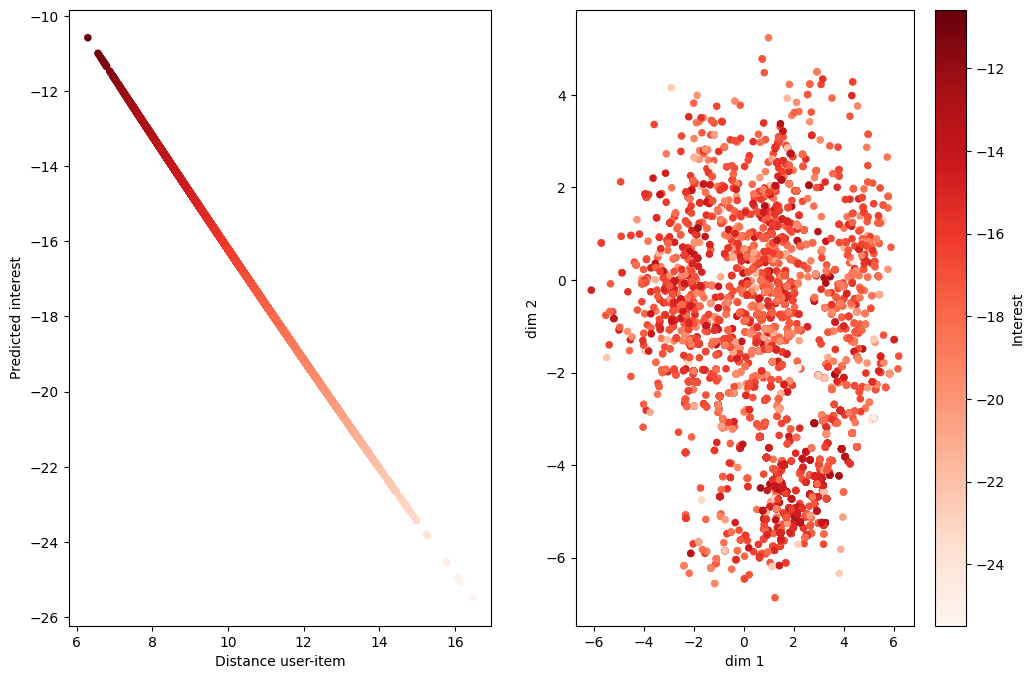

In [13]:
for i, m in enumerate(models):


    print(m)
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))

    cmap = "Reds"
    vmin = result[f'{m}_interest_first'].min()
    vmax = result[f'{m}_interest_first'].max()

    sc1 = axes[0].scatter(
        result[f'{m}_norm_first'],
        result[f'{m}_interest_first'],
        c=result[f'{m}_interest_first'],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=20
    )
    
    axes[0].set_xlabel("Distance user-item")
    axes[0].set_ylabel("Predicted interest")

    sc2 = axes[1].scatter(
        result[f'{m}_emb_dim1'],
        result[f'{m}_emb_dim2'],
        c=result[f'{m}_interest_first'],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=20
    )
    
    axes[1].set_xlabel("dim 1")
    axes[1].set_ylabel("dim 2")
    
    plt.colorbar(sc2, ax=axes[1], label="Interest")

In [14]:
result

,user_id,track_id,ts_nth,occ_nth,ts_first,occ_first,original_norm_first,original_interest_first,original_emb_dim1,original_emb_dim2,extended_norm_first,extended_interest_first,extended_emb_dim1,extended_emb_dim2
0,26,123,1656991051,49,1654063157,0,8.682245,20.791579,4.102709,-0.338211,13.107400,-20.760992,0.273745,-2.224050
1,26,1778,1658532922,49,1654063157,0,9.343121,22.825294,-1.223208,-0.681878,12.252256,-19.524775,1.686536,2.909924
2,26,2548,1659029655,49,1654126622,0,9.151823,22.262956,-1.622320,-0.472056,13.632423,-21.514161,1.736018,3.927212
3,26,1462,1660936255,49,1654203346,0,9.621901,23.606365,1.587534,-1.284382,12.498317,-19.881690,1.820323,2.080458
4,26,2426,1661762981,49,1654063157,0,9.053795,21.966475,0.063263,-0.876510,13.478080,-21.293208,2.026106,1.930623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7516,13201,614,1661303640,49,1658348758,0,9.555494,23.424447,2.490433,-1.473778,10.546562,-17.023906,1.530500,-1.833902
7517,13201,800,1661309008,49,1658348343,0,9.308327,22.724611,0.312367,-2.209686,10.004169,-16.218864,3.365564,-1.871806
7518,13201,464,1661316316,49,1656040091,0,9.515488,23.313602,0.962837,-2.948035,9.522795,-15.500432,5.142496,-2.201032
7519,13201,890,1661321440,49,1658526354,0,8.832761,21.277289,-0.366491,-1.704584,9.311689,-15.184192,3.728531,-2.186111


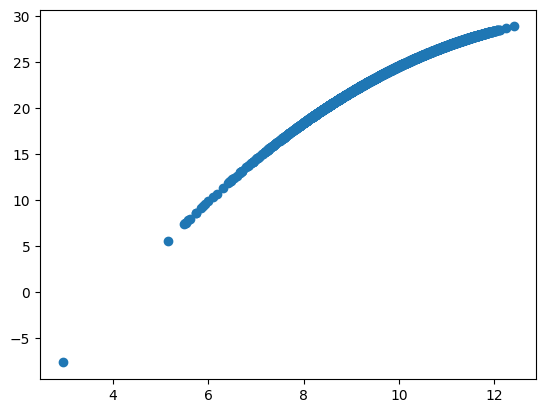

In [15]:
plt.scatter(result['original_norm_first'], result['original_interest_first'])

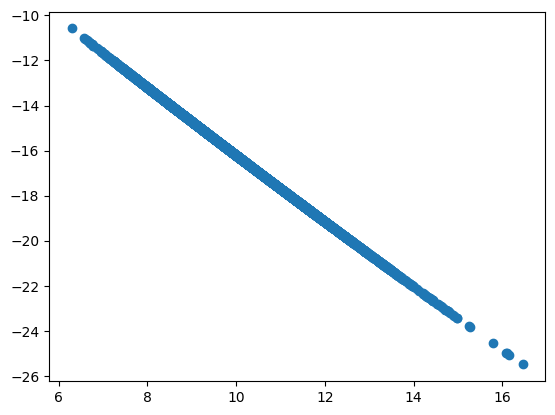

In [16]:
plt.scatter(result['extended_norm_first'], result['extended_interest_first'])

In [17]:
1/0

ZeroDivisionError: division by zero

In [ ]:
n = get_norm(weights, user, item)

get_interest(weights, user, item, n), n

In [ ]:
models = ['original', 'extended']

for m in models:
    df = pd.read_csv(f'../analysis/sim_analysis/{m}.csv')
    
    
    corr_coeff_list = []
    
    space = np.linspace(df['item_dist'].min(), df['item_dist'].max(), 100)
    
    for s in df['split'].unique():
        df_tmp = df[df['split']==s]
    
        dist = df_tmp['item_dist'].to_numpy()
        prob = df_tmp['prob'].to_numpy()
        
        corr_coeff_list.append(stats.pearsonr(dist, prob).statistic)

    print(f'CORR COEFF {m}: {np.mean(corr_coeff_list):.5f} ± {1.96*np.std(corr_coeff_list):.5f}')